In [1]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = '/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv('/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/train.csv')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
titanic_clean = titanic.copy()
titanic_clean = titanic_clean.drop(columns=['Cabin'])

titanic_clean['Age'] = titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(
    lambda x:x.fillna(x.median())
)

titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)
print("전처리후결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n원본 shape: {titanic.shape}")
print("전처리후 shape:{titanic_clean.shape}")

전처리후결측치: 
Series([], dtype: int64)

원본 shape: (891, 12)
전처리후 shape:{titanic_clean.shape}


In [6]:
from scipy import stats

print(titanic[['Age','Fare']].describe())

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


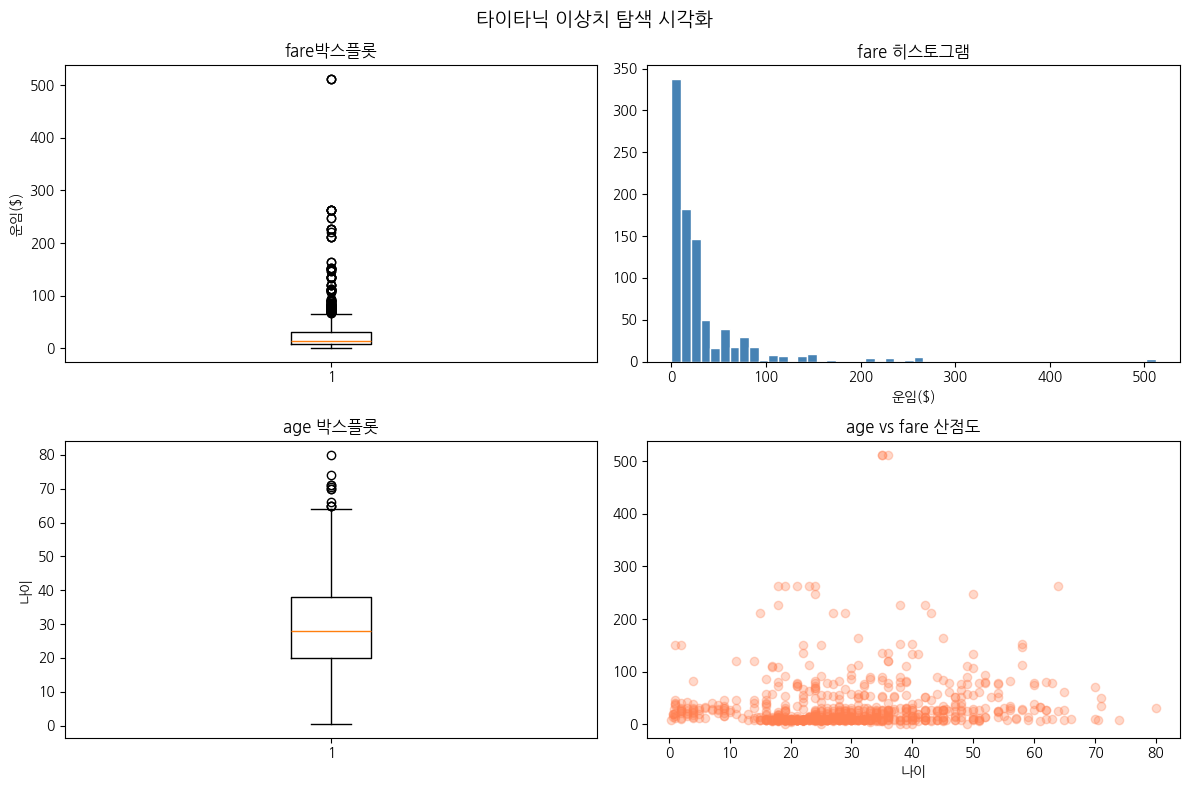

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('타이타닉 이상치 탐색 시각화', fontsize=14)

axes[0,0].boxplot(titanic_clean['Fare'].dropna())
axes[0,0].set_title('fare박스플롯')
axes[0,0].set_ylabel('운임($)')

axes[0,1].hist(titanic['Fare'],bins=50,color='steelblue',edgecolor='white')
axes[0,1].set_title('fare 히스토그램')
axes[0,1].set_xlabel('운임($)')

axes[1,0].boxplot(titanic['Age'].dropna())
axes[1,0].set_title('age 박스플롯')
axes[1,0].set_ylabel('나이')

axes[1,1].scatter(titanic['Age'],titanic['Fare'],alpha=0.3,color='coral')
axes[1,1].set_title('age vs fare 산점도')
axes[1,1].set_xlabel('나이')

plt.tight_layout()
plt.show()

In [10]:
Q1 = titanic_clean['Fare'].quantile(0.25)
Q3 = titanic_clean['Fare'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5* IQR
upper_bound = Q3+1.5*IQR

print(f"Q1: {Q1:.1f}")
print(f"Q3: {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"정상범위:{lower_bound:.1f}~{upper_bound:.1f}")

outlier_mask=(titanic_clean['Fare']<lower_bound) | (titanic_clean['Fare']>upper_bound)
outliers=titanic_clean[outlier_mask]

print("\n 이상치 승객 상위 5명")
print(outliers[['Pclass','Sex','Age','Fare','Survived']].head())

print(f"\n 이상치 개수: {outlier_mask.sum()} ")
print(f"전체 대비 비율: {outlier_mask.mean()*100:.1f}")

Q1: 7.9
Q3: 31.0
IQR: 23.1
정상범위:-26.7~65.6

 이상치 승객 상위 5명
    Pclass     Sex   Age      Fare  Survived
1        1  female  38.0   71.2833         1
27       1    male  19.0  263.0000         0
31       1  female  35.0  146.5208         1
34       1    male  28.0   82.1708         0
52       1  female  49.0   76.7292         1

 이상치 개수: 116 
전체 대비 비율: 13.0


In [11]:
fare_zscore=stats.zscore(titanic_clean['Fare'].dropna())

zscore_series=pd.Series(fare_zscore,index=titanic_clean['Fare'].dropna().index)
outlier_z_mask=zscore_series.abs()>3

print(f"Z-score기준 이상치 수: {outlier_z_mask.sum()}")

fare_clean=titanic_clean[['Fare']].copy()
fare_clean['z-score'] = zscore_series
fare_clean['is_outlier_iqr']=outlier_mask
fare_clean['is_outlier_z']=outlier_z_mask

print('\n 두 방법 비교')
print(f"IQR이상치:{outlier_mask.sum()}개")
print(f"Z-score 이상치: {outlier_z_mask.sum()}개")
print(f"두 방법 모두 이상치:{(outlier_mask & outlier_z_mask).sum()}")

Z-score기준 이상치 수: 20

 두 방법 비교
IQR이상치:116개
Z-score 이상치: 20개
두 방법 모두 이상치:20


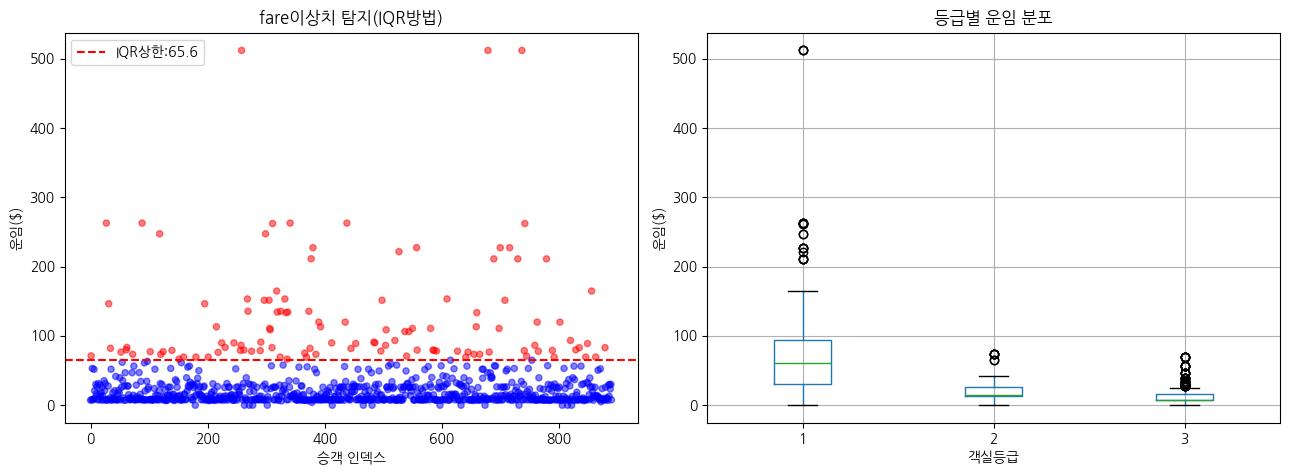

In [15]:
fig, axes = plt.subplots(1,2,figsize=(13,5))

colors=titanic_clean['Fare'].apply(
    lambda x: 'red' if x>upper_bound else 'blue'
)
axes[0].scatter(range(len(titanic_clean)), titanic_clean['Fare'], c=colors, alpha=0.5,s=20)
axes[0].axhline(y=upper_bound, color='red',linestyle='--', label=f"IQR상한:{upper_bound:.1f}")
axes[0].set_title('fare이상치 탐지(IQR방법)')
axes[0].set_xlabel('승객 인덱스')
axes[0].set_ylabel('운임($)')
axes[0].legend()

titanic_clean.boxplot(column='Fare',by='Pclass',ax=axes[1])
axes[1].set_title('등급별 운임 분포')
axes[1].set_xlabel('객실등급')
axes[1].set_ylabel('운임($)')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [16]:
titanic_no_outlier=titanic[~outlier_mask].copy()

print(f"원본 행 수: {len(titanic_clean)}")
print(f"이상치 제거 후: {len(titanic_no_outlier)}")

comparison=pd.DataFrame({
    '원본':titanic_clean['Fare'].describe(),
    '이상치제거후':titanic_no_outlier['Fare'].describe()
}).round(2)
display(comparison)

원본 행 수: 891
이상치 제거 후: 775


,원본,이상치제거후
count,891.00,775.00
mean,32.20,17.82
std,49.69,13.58
min,0.00,0.00
25%,7.91,7.90
50%,14.45,13.00
75%,31.00,26.00
max,512.33,65.00


캡핑 전 최대값: 512.3292
캡핑 후 최대값:  512.3292
행수변화없음:  891


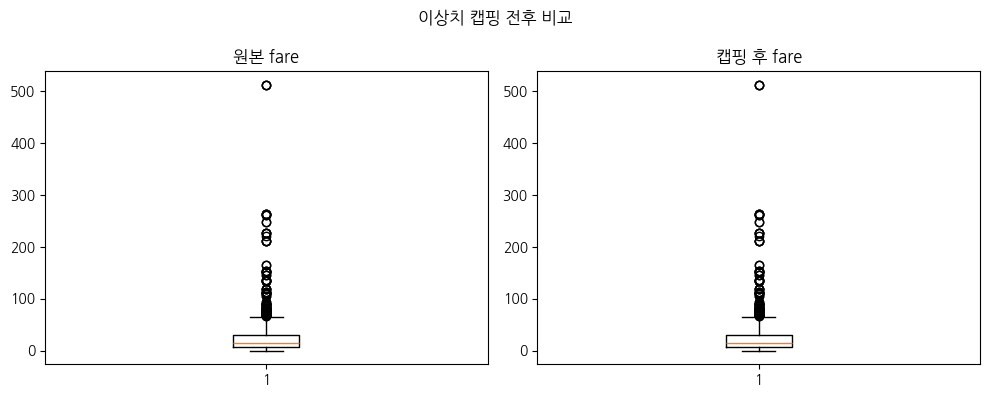

In [19]:
titanic_clipped=titanic_clean.copy()
titanic_clipped['Fare_clipped'] = titanic_clipped['Fare'].clip(
    lower=max(lower_bound,0)
)

print('캡핑 전 최대값:',titanic_clean['Fare'].max())
print('캡핑 후 최대값: ',titanic_clipped['Fare_clipped'].max())
print('행수변화없음: ',len(titanic_clipped))

fig, axes = plt.subplots(1,2,figsize=(10,4))
axes[0].boxplot(titanic_clean['Fare'])
axes[0].set_title('원본 fare')
axes[1].boxplot(titanic_clipped['Fare_clipped'])
axes[1].set_title('캡핑 후 fare')

plt.suptitle('이상치 캡핑 전후 비교')
plt.tight_layout()
plt.show()

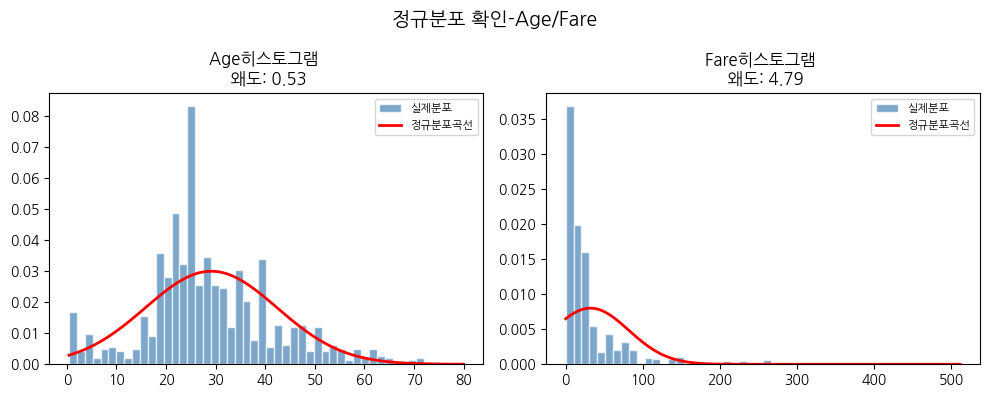

In [21]:
fig,axes = plt.subplots(1,2,figsize=(10,4))
fig.suptitle('정규분포 확인-Age/Fare',fontsize=14)

cols=['Age','Fare']

for i,col in enumerate(cols):
  data=titanic_clean[col].dropna()
  ax1 = axes[i]
  ax1.hist(data,bins=50,density=True,color='steelblue',edgecolor='white',alpha=0.7,label='실제분포')

  x = np.linspace(data.min(), data.max(),100)
  ax1.plot(x,stats.norm.pdf(x,data.mean(),data.std()),color='red',linewidth=2,label='정규분포곡선')
  ax1.set_title(f'{col}히스토그램 \n 왜도: {data.skew():.2f}')
  ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

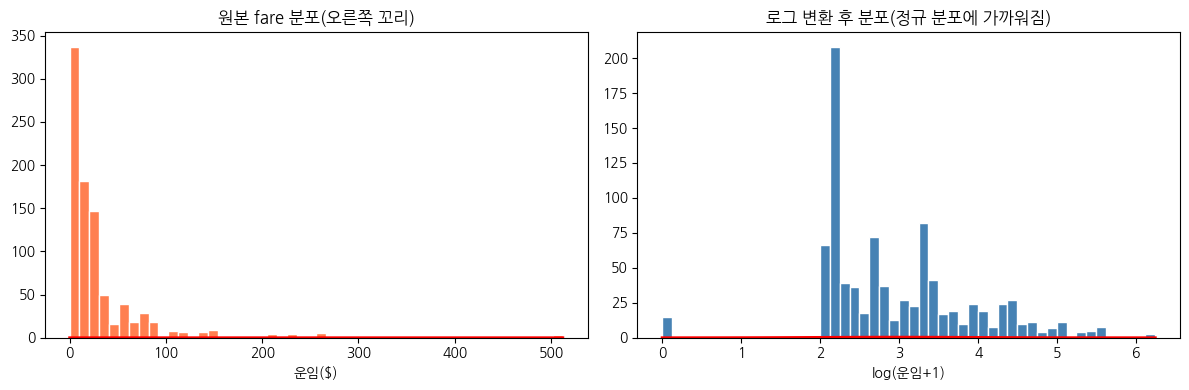

원본 fare왜도: 4.79
로그변환 후 왜도: 0.39


In [22]:
titanic_log = titanic_clean.copy()
titanic_log['Fare_log'] = np.log1p(titanic_clean['Fare'])

fig,axes=plt.subplots(1,2,figsize=(12,4))

axes[0].hist(titanic_clean['Fare'],bins=50,color='coral',edgecolor='white')
x=np.linspace(titanic_clean['Fare'].min(),titanic_clean['Fare'].max(),100)
axes[0].plot(x,stats.norm.pdf(x,titanic_clean['Fare'].mean(),titanic_clean['Fare'].std()),color='red',linewidth=2)
axes[0].set_title('원본 fare 분포(오른쪽 꼬리)')
axes[0].set_xlabel('운임($)')

axes[1].hist(titanic_log['Fare_log'],bins=50,color='steelblue',edgecolor='white')
x=np.linspace(titanic_log['Fare_log'].min(),titanic_log['Fare_log'].max(),100)
axes[1].plot(x,stats.norm.pdf(x,titanic_log['Fare_log'].mean(),titanic_log['Fare_log'].std()),color='red',linewidth=2)
axes[1].set_title('로그 변환 후 분포(정규 분포에 가까워짐)')
axes[1].set_xlabel('log(운임+1)')
plt.tight_layout()
plt.show()

print(f"원본 fare왜도: {titanic_clean['Fare'].skew():.2f}")
print(f"로그변환 후 왜도: {titanic_log['Fare_log'].skew():.2f}")


다변수이상치:5개
       Age      Fare     Age_z    Fare_z
195  58.00  146.5208  2.172495  2.301729
268  58.00  153.4625  2.172495  2.441498
297   2.00  151.5500 -2.038995  2.402990
305   0.92  151.5500 -2.120216  2.402990
438  64.00  263.0000  2.623727  4.647001


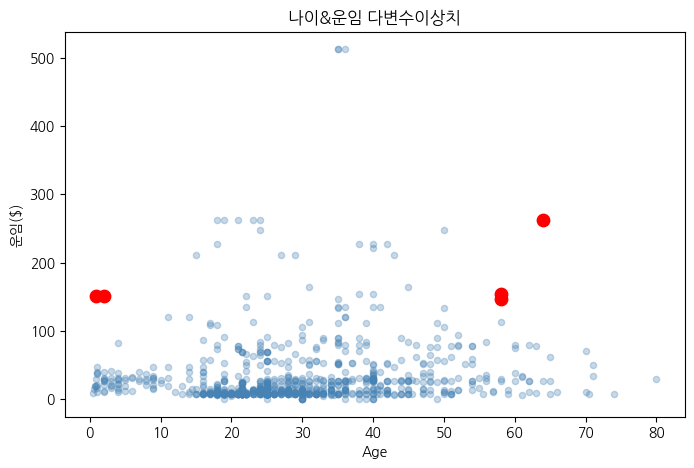

In [23]:
titanic_bivar=titanic_clean[['Age','Fare']].dropna().copy()

titanic_bivar['Age_z']= stats.zscore(titanic_bivar['Age'])
titanic_bivar['Fare_z'] = stats.zscore(titanic_bivar['Fare'])

both_extreme=(titanic_bivar['Age_z'].abs()>2)&(titanic_bivar['Fare_z'].abs()>2)

print(f"다변수이상치:{both_extreme.sum()}개")
print(titanic_bivar[both_extreme])

plt.figure(figsize=(8,5))
normal=~both_extreme
plt.scatter(titanic_bivar.loc[normal,'Age'],
            titanic_bivar.loc[normal,'Fare'],
            alpha=0.3,color='steelblue',label='정상',s=20)
plt.scatter(titanic_bivar.loc[both_extreme,'Age'],
            titanic_bivar.loc[both_extreme,'Fare'],
            color='red',label='다변수이상치',s=80,zorder=5)

plt.xlabel('Age')
plt.ylabel('운임($)')
plt.title('나이&운임 다변수이상치')
plt.show()

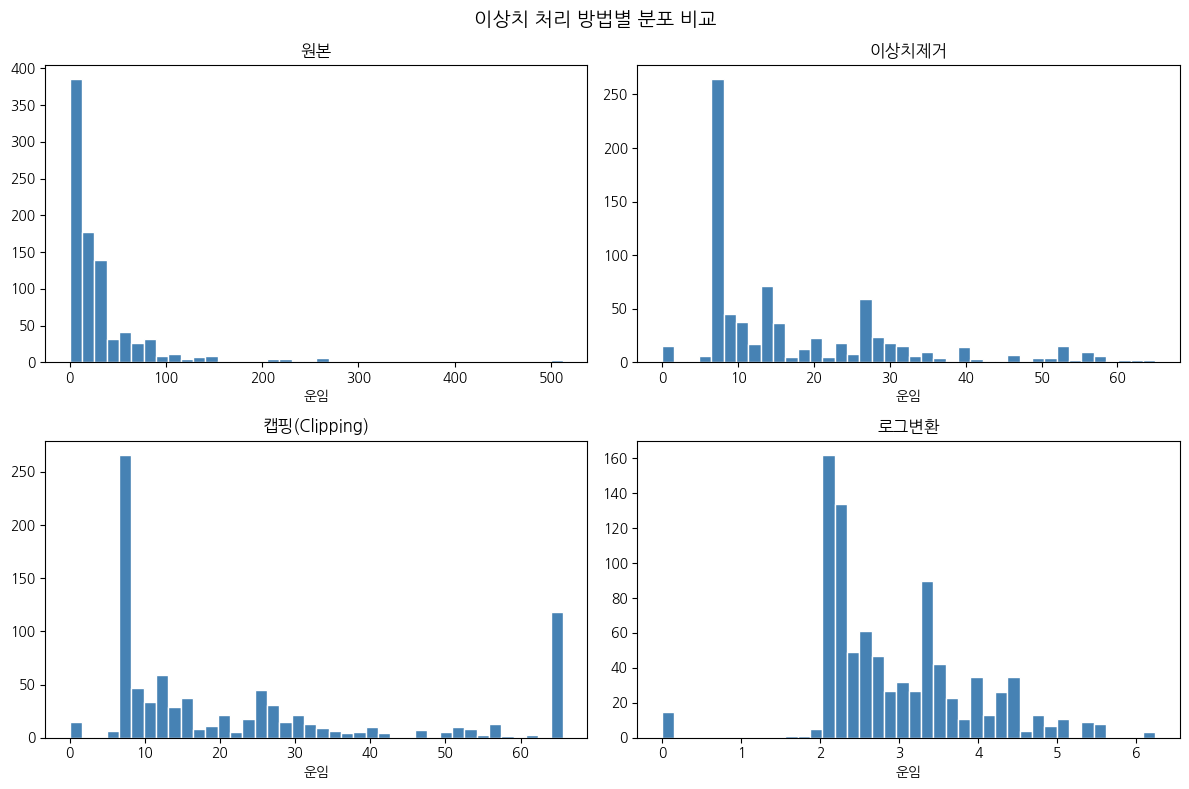

,원본,제거,캡핑,로그변환
count,891.00,775.00,891.00,891.00
mean,32.20,17.82,24.05,2.96
std,49.69,13.58,20.48,0.97
min,0.00,0.00,0.00,0.00
25%,7.91,7.90,7.91,2.19
50%,14.45,13.00,14.45,2.74
75%,31.00,26.00,31.00,3.47
max,512.33,65.00,65.63,6.24


In [24]:
fare_original=titanic_clean['Fare']

fare_dropped=titanic_clean.loc[~outlier_mask,'Fare']

fare_clipped=titanic_clean['Fare'].clip(upper=upper_bound)

fare_log = np.log1p(titanic_clean['Fare'])

fig,axes=plt.subplots(2,2 ,figsize=(12,8))
fig.suptitle('이상치 처리 방법별 분포 비교',fontsize=14)

for ax, data ,title in zip(
    axes.flatten(),
    [fare_original, fare_dropped, fare_clipped, fare_log],['원본','이상치제거','캡핑(Clipping)','로그변환']
):

  ax.hist(data,bins=40,edgecolor='white',color='steelblue')
  ax.set_title(title)
  ax.set_xlabel('운임')

plt.tight_layout()
plt.show()

summary=pd.DataFrame({
    '원본': fare_original.describe(),
    '제거': fare_dropped.describe(),
    '캡핑': fare_clipped.describe(),
    '로그변환': fare_log.describe()
}).round(2)
display(summary)
